In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

RANDOM_STATE = 42

In [10]:
df = pd.read_csv("/content/data.csv")

print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(df["Bankrupt?"].value_counts())

print("\nBankruptcy rate:")
print(f"{df['Bankrupt?'].mean():.2%}")

df.head()

Dataset shape: (6819, 96)

Target distribution:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Bankruptcy rate:
3.23%


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [11]:
print("Total missing values:", df.isnull().sum().sum())

print("\nData types:")
print(df.dtypes.value_counts())

print("\nNumber of duplicate rows:", df.duplicated().sum())

Total missing values: 0

Data types:
float64    93
int64       3
Name: count, dtype: int64

Number of duplicate rows: 0


In [12]:
X = df.drop(columns=["Bankrupt?"])
y = df["Bankrupt?"]

print("Number of financial variables:", X.shape[1])
print("Number of observations:", X.shape[0])

Number of financial variables: 95
Number of observations: 6819


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining bankruptcy rate:", f"{y_train.mean():.2%}")
print("Test bankruptcy rate:", f"{y_test.mean():.2%}")

Training set: (5455, 95)
Test set: (1364, 95)

Training bankruptcy rate: 3.23%
Test bankruptcy rate: 3.23%


In [14]:
all_results = []

def evaluate_model(model_name, y_true, y_proba):

    y_pred = (y_proba >= 0.50).astype(int)

    results = {
        "Model": model_name,
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0)
    }

    all_results.append(results)

    print(f"\n{model_name}")
    print("-" * 50)

    for metric, value in results.items():
        if metric != "Model":
            print(f"{metric}: {value:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    return results

In [15]:
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        class_weight="balanced",
        max_iter=3000,
        random_state=RANDOM_STATE
    ))
])

baseline_model.fit(X_train, y_train)

baseline_proba = baseline_model.predict_proba(X_test)[:, 1]

evaluate_model(
    "Baseline Logistic Regression",
    y_test,
    baseline_proba
)


Baseline Logistic Regression
--------------------------------------------------
ROC-AUC: 0.9171
PR-AUC: 0.3190
Accuracy: 0.8783
Precision: 0.1856
Recall: 0.8182
F1 Score: 0.3025

Confusion Matrix:
[[1162  158]
 [   8   36]]


{'Model': 'Baseline Logistic Regression',
 'ROC-AUC': np.float64(0.9171487603305785),
 'PR-AUC': np.float64(0.3189765045643962),
 'Accuracy': 0.8782991202346041,
 'Precision': 0.18556701030927836,
 'Recall': 0.8181818181818182,
 'F1 Score': 0.3025210084033613}

In [16]:
l1_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=3000,
        random_state=RANDOM_STATE
    ))
])

param_grid = {
    "logistic__C": [0.001, 0.01, 0.1, 1, 10]
}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

grid_search = GridSearchCV(
    estimator=l1_pipeline,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

l1_model = grid_search.best_estimator_

print("Best C:", grid_search.best_params_["logistic__C"])
print("Best CV PR-AUC:", round(grid_search.best_score_, 4))

Best C: 0.01
Best CV PR-AUC: 0.3765


In [17]:
l1_proba = l1_model.predict_proba(X_test)[:, 1]

evaluate_model(
    "L1-Regularized Logistic Regression",
    y_test,
    l1_proba
)


L1-Regularized Logistic Regression
--------------------------------------------------
ROC-AUC: 0.9329
PR-AUC: 0.3725
Accuracy: 0.8563
Precision: 0.1637
Recall: 0.8409
F1 Score: 0.2741

Confusion Matrix:
[[1131  189]
 [   7   37]]


{'Model': 'L1-Regularized Logistic Regression',
 'ROC-AUC': np.float64(0.9328512396694215),
 'PR-AUC': np.float64(0.37250927410289714),
 'Accuracy': 0.8563049853372434,
 'Precision': 0.16371681415929204,
 'Recall': 0.8409090909090909,
 'F1 Score': 0.2740740740740741}

In [18]:
coefficients = l1_model.named_steps["logistic"].coef_[0]

feature_importance_l1 = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
})

selected_features = feature_importance_l1[
    feature_importance_l1["Coefficient"] != 0
].sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print(
    f"Features retained: {len(selected_features)} "
    f"out of {X.shape[1]}"
)

selected_features.head(15)

Features retained: 17 out of 95


,Feature,Coefficient,Absolute_Coefficient
36,Debt ratio %,0.600356,0.600356
37,Net worth/Assets,-0.538010,0.538010
18,Persistent EPS in the Last Four Seasons,-0.536162,0.536162
85,Net Income to Total Assets,-0.476832,0.476832
44,Total Asset Turnover,-0.139956,0.139956
73,Cash Turnover Rate,-0.134827,0.134827
80,Cash Flow to Liability,-0.109720,0.109720
0,ROA(C) before interest and depreciation befor...,-0.103627,0.103627
48,Fixed Assets Turnover Frequency,0.101297,0.101297
49,Net Worth Turnover Rate (times),-0.079210,0.079210


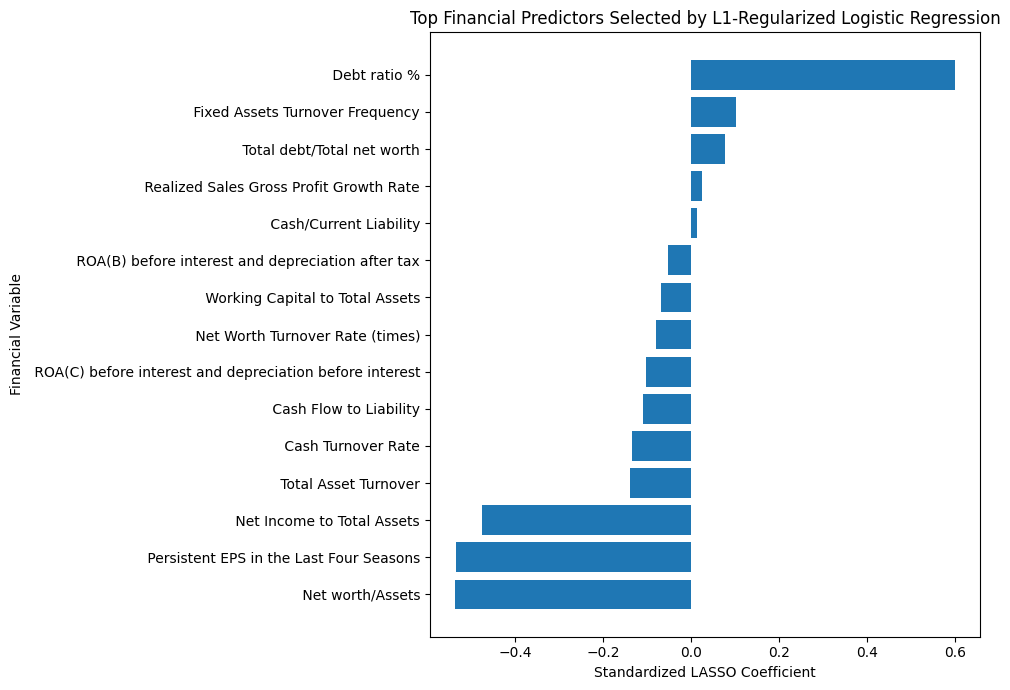

In [19]:
top_lasso = selected_features.head(15).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_lasso["Feature"],
    top_lasso["Coefficient"]
)

plt.xlabel("Standardized LASSO Coefficient")
plt.ylabel("Financial Variable")
plt.title("Top Financial Predictors Selected by L1-Regularized Logistic Regression")

plt.tight_layout()
plt.show()

In [20]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_proba = rf_model.predict_proba(X_test)[:, 1]

evaluate_model(
    "Random Forest",
    y_test,
    rf_proba
)


Random Forest
--------------------------------------------------
ROC-AUC: 0.9496
PR-AUC: 0.5131
Accuracy: 0.9589
Precision: 0.4062
Recall: 0.5909
F1 Score: 0.4815

Confusion Matrix:
[[1282   38]
 [  18   26]]


{'Model': 'Random Forest',
 'ROC-AUC': np.float64(0.9495867768595041),
 'PR-AUC': np.float64(0.5131156846033964),
 'Accuracy': 0.9589442815249267,
 'Precision': 0.40625,
 'Recall': 0.5909090909090909,
 'F1 Score': 0.48148148148148145}

In [21]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

rf_importance.head(15)

,Feature,Importance
39,Borrowing dependency,0.050598
18,Persistent EPS in the Last Four Seasons,0.048129
35,Total debt/Total net worth,0.045760
85,Net Income to Total Assets,0.045177
9,Continuous interest rate (after tax),0.041534
37,Net worth/Assets,0.036630
36,Debt ratio %,0.034691
94,Equity to Liability,0.033912
67,Retained Earnings to Total Assets,0.030852
68,Total income/Total expense,0.029932


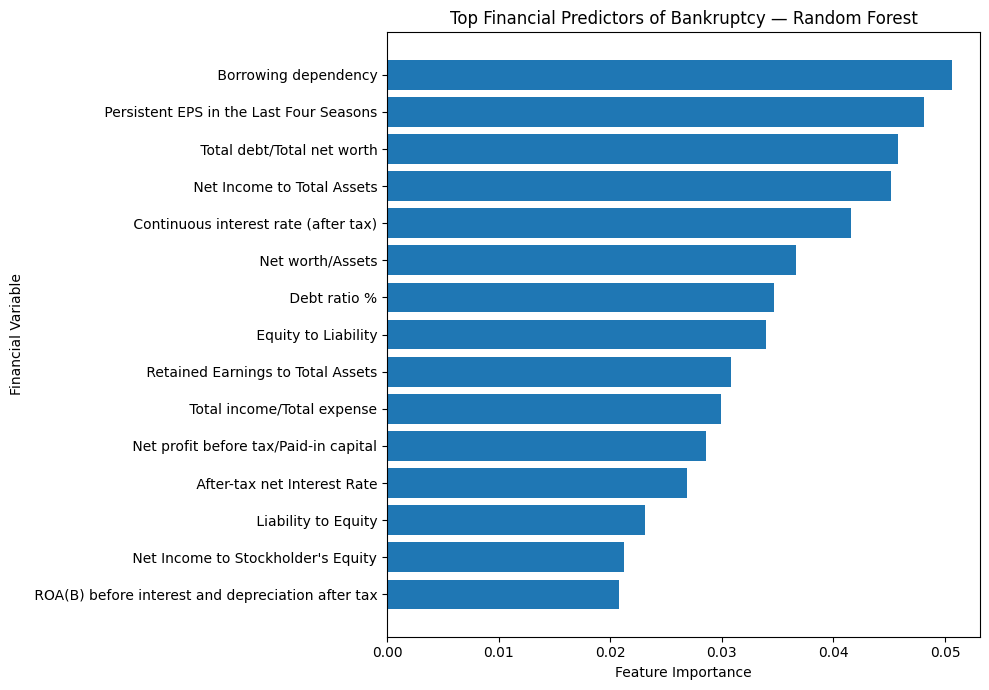

In [22]:
top_rf = rf_importance.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))

plt.barh(
    top_rf["Feature"],
    top_rf["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Financial Variable")
plt.title("Top Financial Predictors of Bankruptcy — Random Forest")

plt.tight_layout()
plt.show()

In [23]:
results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    "PR-AUC",
    ascending=False
)

results_df

,Model,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.949587,0.513116,0.958944,0.406250,0.590909,0.481481
1,L1-Regularized Logistic Regression,0.932851,0.372509,0.856305,0.163717,0.840909,0.274074
0,Baseline Logistic Regression,0.917149,0.318977,0.878299,0.185567,0.818182,0.302521


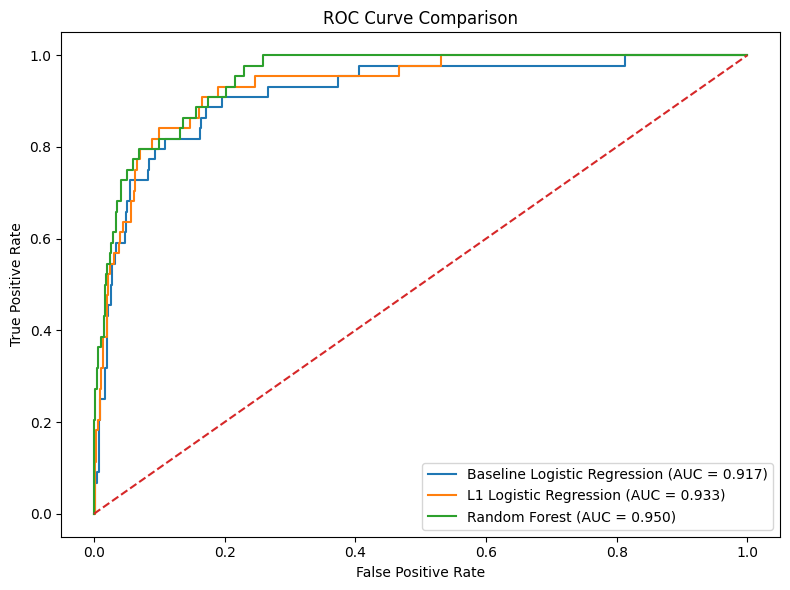

In [24]:
models_proba = {
    "Baseline Logistic Regression": baseline_proba,
    "L1 Logistic Regression": l1_proba,
    "Random Forest": rf_proba
}

plt.figure(figsize=(8, 6))

for name, probabilities in models_proba.items():

    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc_score = roc_auc_score(y_test, probabilities)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.tight_layout()
plt.show()

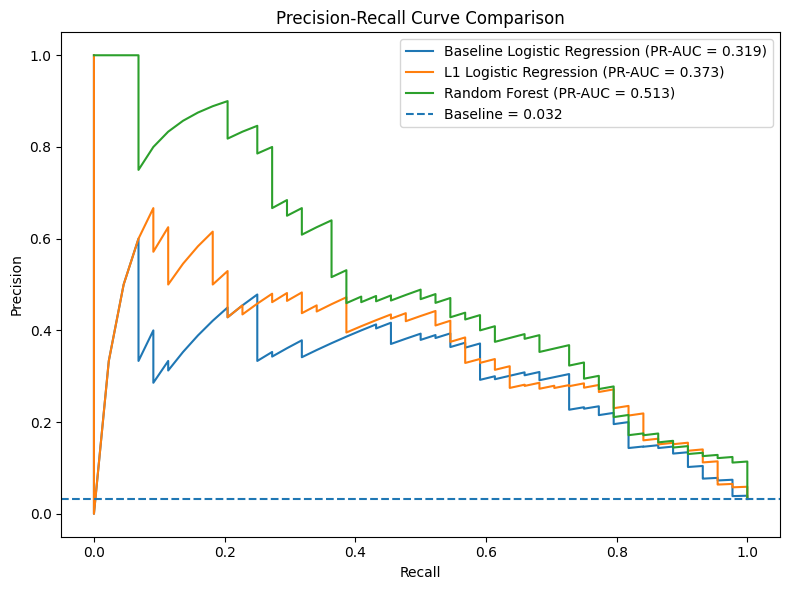

In [25]:
plt.figure(figsize=(8, 6))

for name, probabilities in models_proba.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities
    )

    ap_score = average_precision_score(
        y_test,
        probabilities
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (PR-AUC = {ap_score:.3f})"
    )

baseline_rate = y_test.mean()

plt.axhline(
    baseline_rate,
    linestyle="--",
    label=f"Baseline = {baseline_rate:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")

plt.legend()
plt.tight_layout()
plt.show()

In [29]:
best_proba = rf_proba
best_model_name = "Random Forest"

In [30]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    best_proba
)

# Calculate F1 score at each threshold
f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]

print("Best model:", best_model_name)
print("Optimal threshold based on F1:", round(best_threshold, 4))
print("Best F1 score:", round(f1_scores[best_index], 4))

Best model: Random Forest
Optimal threshold based on F1: 0.6021
Best F1 score: 0.5053


In [31]:
optimal_pred = (
    best_proba >= best_threshold
).astype(int)

print(classification_report(
    y_test,
    optimal_pred,
    digits=4
))

print("Confusion Matrix:")
print(confusion_matrix(
    y_test,
    optimal_pred
))

              precision    recall  f1-score   support

           0     0.9848    0.9795    0.9821      1320
           1     0.4706    0.5455    0.5053        44

    accuracy                         0.9655      1364
   macro avg     0.7277    0.7625    0.7437      1364
weighted avg     0.9682    0.9655    0.9668      1364

Confusion Matrix:
[[1293   27]
 [  20   24]]
